
# Milestone 2 — Advanced Data Analysis & Feature Engineering
### Sales Forecasting and Demand Prediction — AI & Data Science Track

Input: `cleaned_final_rossmann_data.csv`, the cleaned output of Milestone 1 (844,392 rows, 39 columns, 1,115 stores, Jan 2013 – Jul 2015, one row per store per day).

This notebook picks up where Milestone 1 left off and gets the data ready for modeling in Milestone 3:

1. **Advanced Data Analysis** — trend, seasonality, stationarity (ADF), correlations
2. **Feature Engineering** — rolling stats, extra lag features, cyclical encodings, aggregations, external factors
3. **Data Visualization** — trend charts, promo/holiday effects, an interactive dashboard (dark theme)
4. **Feature Selection** — four methods, combined into one final feature list for Milestone 3




## 0. Setup & Data Loading

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import plotly.graph_objects as go
import plotly.io as pio

BG = "#0E1117"
PANEL = "#161B26"
GRID = "#262B36"
TEXT = "#E8E8E8"
MUTED = "#9AA1AC"

ACCENT = "#3FA9F5"
ACCENT2 = "#2EC4B6"
WARN = "#FFB84D"
NEG = "#FF5C8A"
PURPLE = "#B48EAD"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": TEXT,
    "grid.color": GRID,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "legend.facecolor": PANEL,
    "legend.edgecolor": GRID,
    "legend.labelcolor": TEXT,
    "figure.figsize": (12, 5),
})

pio.templates.default = "plotly_dark"

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


In [2]:
DATA_PATH = "/content/cleaned_final_rossmann_data.zip"

df = pd.read_csv(DATA_PATH, compression="zip")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['Date'].min().date()}  ->  {df['Date'].max().date()}")
print(f"Stores: {df['Store'].nunique():,}")
df.head()

Shape: 844,392 rows x 39 columns
Date range: 2013-01-01  ->  2015-07-31
Stores: 1,115


,Store,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionData_Missing,Promo2Data_Missing,Year,Month,Day,WeekOfYear,DayOfYear,Quarter,CompetitionOpen,Promo2Active,Sales_Lag_7,Sales_Lag_30,Sales_Log,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,DayOfWeek_7
0,1,2013-01-02,5530,668,1,0,0,1,-0.649869,9,2008,0,0,0,NaN,False,True,2013,1,2,1,2,1,52,0,-1.998247,-1.331923,8.618124,False,True,False,False,False,False,True,False,False,False,False
1,1,2013-01-03,4327,578,1,0,0,1,-0.649869,9,2008,0,0,0,NaN,False,True,2013,1,3,1,3,1,52,0,-1.998247,-1.331923,8.372861,False,True,False,False,False,False,False,True,False,False,False
2,1,2013-01-04,4486,619,1,0,0,1,-0.649869,9,2008,0,0,0,NaN,False,True,2013,1,4,1,4,1,52,0,-1.998247,-1.331923,8.408940,False,True,False,False,False,False,False,False,True,False,False
3,1,2013-01-05,4997,635,1,0,0,1,-0.649869,9,2008,0,0,0,NaN,False,True,2013,1,5,1,5,1,52,0,-1.998247,-1.331923,8.516793,False,True,False,False,False,False,False,False,False,True,False
4,1,2013-01-07,7176,785,1,1,0,1,-0.649869,9,2008,0,0,0,NaN,False,True,2013,1,7,2,7,1,52,0,-1.998247,-1.331923,8.878637,False,True,False,False,False,False,False,False,False,False,False


`PromoInterval` shows `NaN` for every store with `Promo2 = 0` — those stores were never enrolled in the long-term promo, so there's no interval to record. It's already handled functionally through the derived `Promo2Active` flag (not used as a raw feature anywhere downstream), so this fill is purely cosmetic, just to keep the dataframe tidy to look at.

In [3]:

df["PromoInterval"] = df["PromoInterval"].fillna("None")


Every row here already has `Open == 1` (closed-store rows were dropped in Milestone 1), so `Sales` reflects real organic demand — this is the right series to run time-series and correlation analysis on.

## 1. Advanced Data Analysis

### 1.1 Building the Daily Aggregate Sales Series

In [4]:

daily = df.groupby("Date").agg(
    Total_Sales=("Sales", "sum"),
    Avg_Sales=("Sales", "mean"),
    Open_Stores=("Store", "nunique"),
    Avg_Customers=("Customers", "mean"),
).reset_index()

daily = daily.set_index("Date").asfreq("D")
daily["Total_Sales"] = daily["Total_Sales"].interpolate(limit_direction="both")
daily["Avg_Sales"] = daily["Avg_Sales"].interpolate(limit_direction="both")

print(daily["Total_Sales"].describe().round(2))


count         942.00
mean      6234798.96
std       3130535.87
min         97235.00
25%       5675832.25
50%       6580354.00
75%       8174898.75
max      15623548.00
Name: Total_Sales, dtype: float64


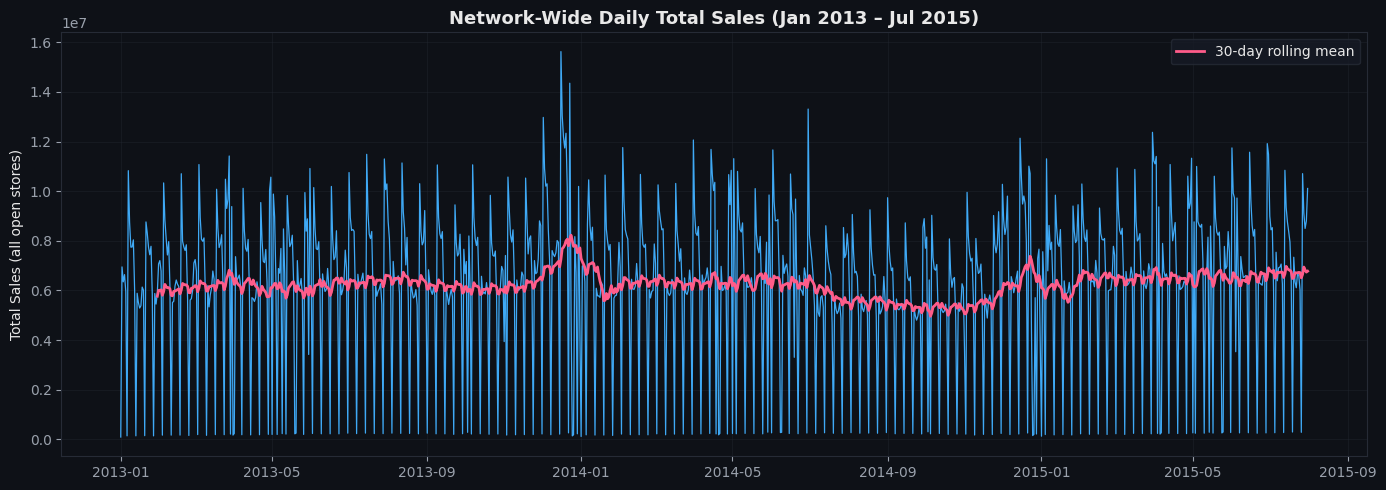

In [5]:

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily["Total_Sales"], color=ACCENT, linewidth=0.9)
ax.plot(daily.index, daily["Total_Sales"].rolling(30).mean(), color=NEG, linewidth=2, label="30-day rolling mean")
ax.set_title("Network-Wide Daily Total Sales (Jan 2013 – Jul 2015)", color=TEXT)
ax.set_ylabel("Total Sales (all open stores)")
ax.legend()
plt.tight_layout()
plt.show()


### 1.2 Time Series Decomposition — Trend, Seasonality, Cyclic Patterns

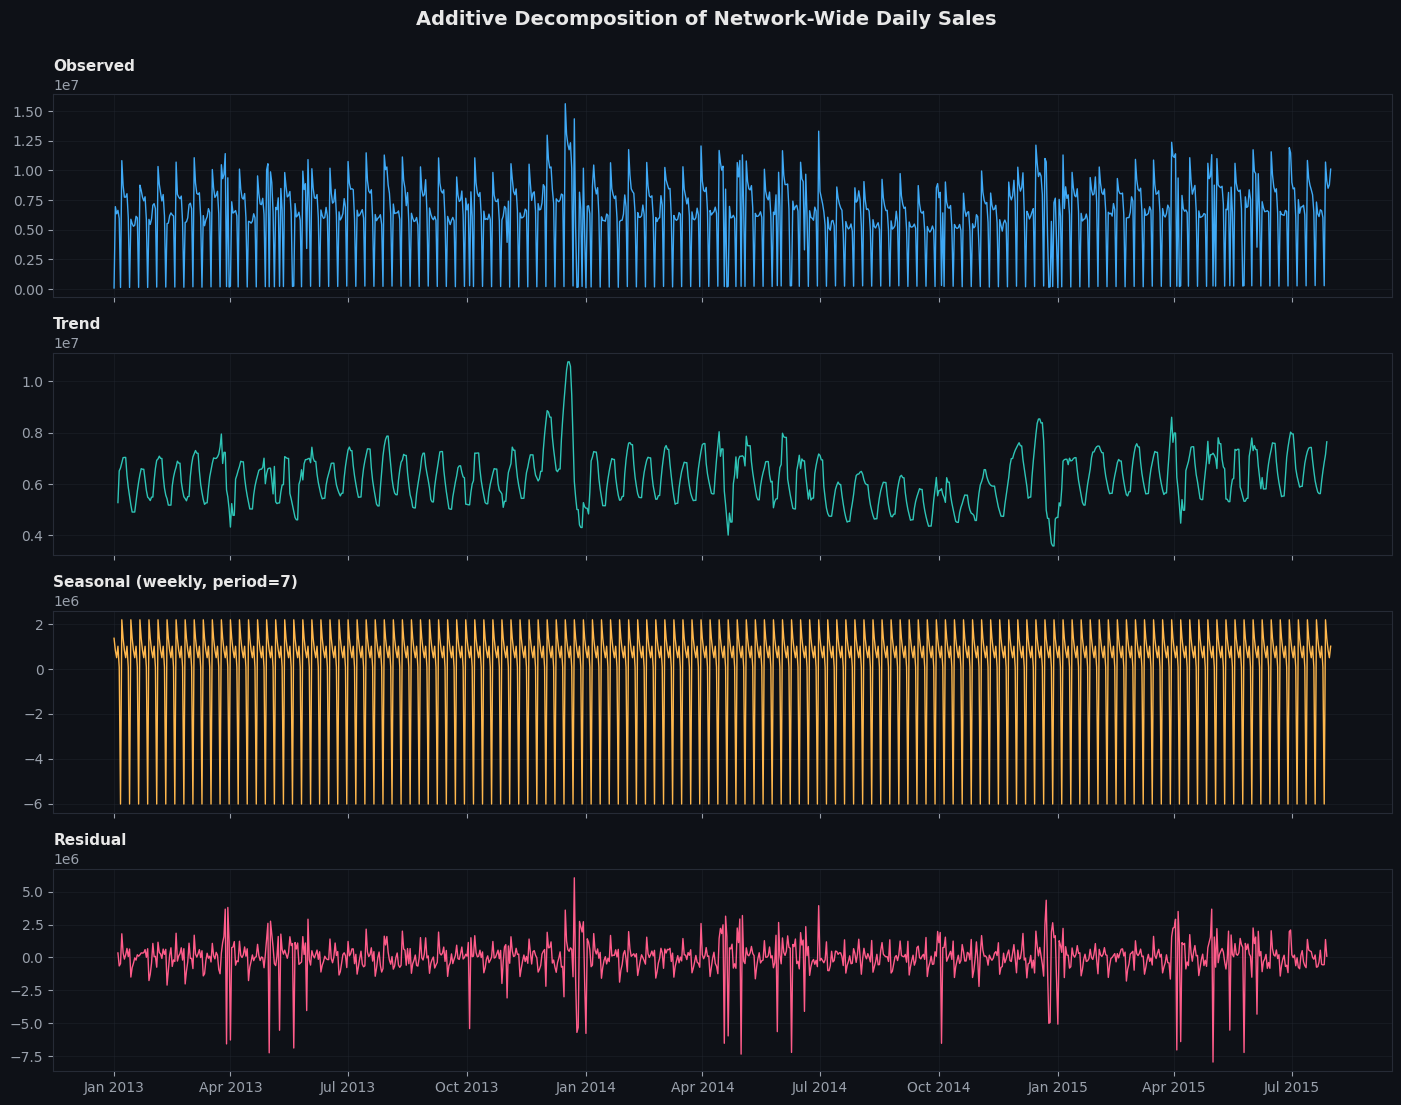

Trend component: 5,279,455 -> 7,648,351  (+44.9% over the observed window)
Seasonal component range: [-6,013,815, 2,197,390]
Residual std. dev.: 1,391,359


In [6]:

decomposition = seasonal_decompose(daily["Total_Sales"], model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
components = [
    (daily["Total_Sales"], "Observed", ACCENT),
    (decomposition.trend, "Trend", ACCENT2),
    (decomposition.seasonal, "Seasonal (weekly, period=7)", WARN),
    (decomposition.resid, "Residual", NEG),
]
for ax, (series, title, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=1)
    ax.set_title(title, loc="left", fontsize=11, color=TEXT)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.suptitle("Additive Decomposition of Network-Wide Daily Sales", fontsize=14, fontweight="bold", y=1.00, color=TEXT)
plt.tight_layout()
plt.show()

trend_start = decomposition.trend.dropna().iloc[0]
trend_end = decomposition.trend.dropna().iloc[-1]
pct_change = (trend_end - trend_start) / trend_start * 100
print(f"Trend component: {trend_start:,.0f} -> {trend_end:,.0f}  ({pct_change:+.1f}% over the observed window)")
print(f"Seasonal component range: [{decomposition.seasonal.min():,.0f}, {decomposition.seasonal.max():,.0f}]")
print(f"Residual std. dev.: {decomposition.resid.std():,.0f}")


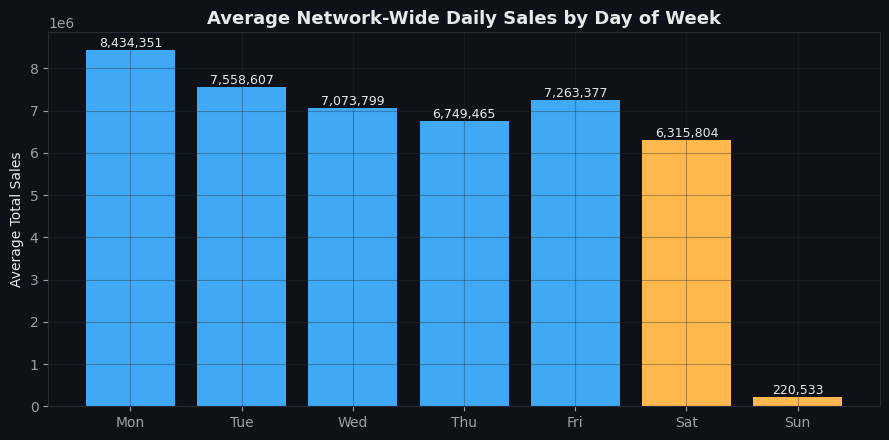

DOW
Mon    8434351.0
Tue    7558607.0
Wed    7073799.0
Thu    6749465.0
Fri    7263377.0
Sat    6315804.0
Sun     220533.0
Name: Total_Sales, dtype: float64


In [7]:

dow_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
daily_dow = daily.copy()
daily_dow["DOW"] = daily_dow.index.dayofweek.map(dow_map)
dow_order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_avg = daily_dow.groupby("DOW")["Total_Sales"].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(dow_avg.index, dow_avg.values, color=[ACCENT if d not in ("Sat","Sun") else WARN for d in dow_order])
ax.set_title("Average Network-Wide Daily Sales by Day of Week", color=TEXT)
ax.set_ylabel("Average Total Sales")
for b, v in zip(bars, dow_avg.values):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9, color=TEXT)
plt.tight_layout()
plt.show()

print(dow_avg.round(0))


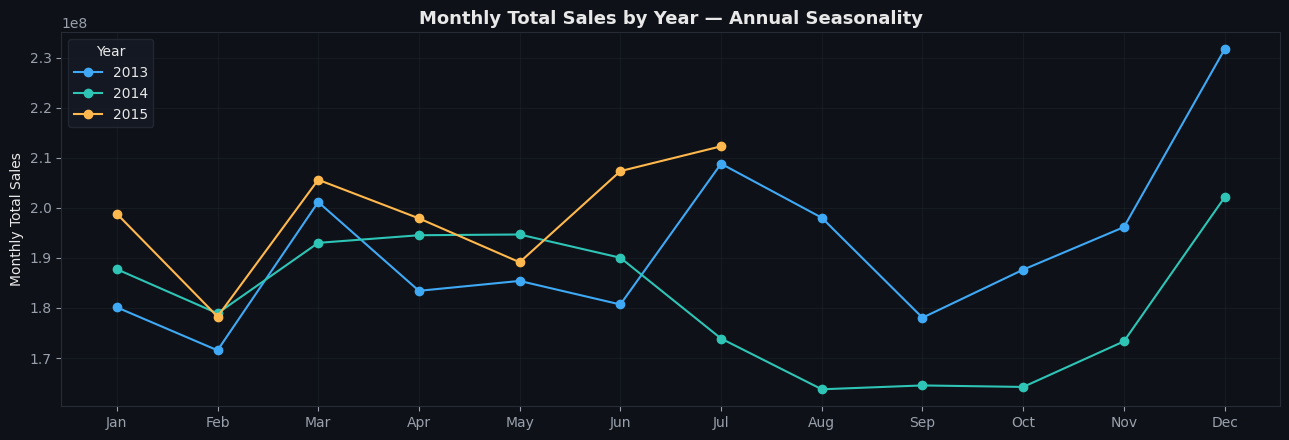

In [8]:

monthly = daily["Total_Sales"].resample("MS").sum()
year_colors = [ACCENT, ACCENT2, WARN, PURPLE]

fig, ax = plt.subplots(figsize=(13, 4.5))
for i, yr in enumerate(monthly.index.year.unique()):
    yr_data = monthly[monthly.index.year == yr]
    ax.plot(yr_data.index.month, yr_data.values, marker="o", label=str(yr), color=year_colors[i % len(year_colors)])
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Monthly Total Sales by Year — Annual Seasonality", color=TEXT)
ax.set_ylabel("Monthly Total Sales")
ax.legend(title="Year")
plt.tight_layout()
plt.show()


### 1.3 Stationarity Testing — Augmented Dickey-Fuller (ADF) Test

In [9]:

def run_adf(series, label):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.6f}")
    print(f"# Lags Used   : {result[2]}")
    print(f"# Observations: {result[3]}")
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value:.4f}")
    verdict = "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY"
    print(f"Verdict (alpha=0.05): {verdict}\n")
    return result[1]

pval_level = run_adf(daily["Total_Sales"], "Total_Sales (level)")


--- ADF Test: Total_Sales (level) ---
ADF Statistic : -4.7616
p-value       : 0.000064
# Lags Used   : 20
# Observations: 921
Critical Value (1%): -3.4375
Critical Value (5%): -2.8647
Critical Value (10%): -2.5684
Verdict (alpha=0.05): STATIONARY



In [10]:

daily["Total_Sales_diff1"] = daily["Total_Sales"].diff()
pval_diff = run_adf(daily["Total_Sales_diff1"], "Total_Sales (1st difference)")


--- ADF Test: Total_Sales (1st difference) ---
ADF Statistic : -14.0085
p-value       : 0.000000
# Lags Used   : 19
# Observations: 921
Critical Value (1%): -3.4375
Critical Value (5%): -2.8647
Critical Value (10%): -2.5684
Verdict (alpha=0.05): STATIONARY



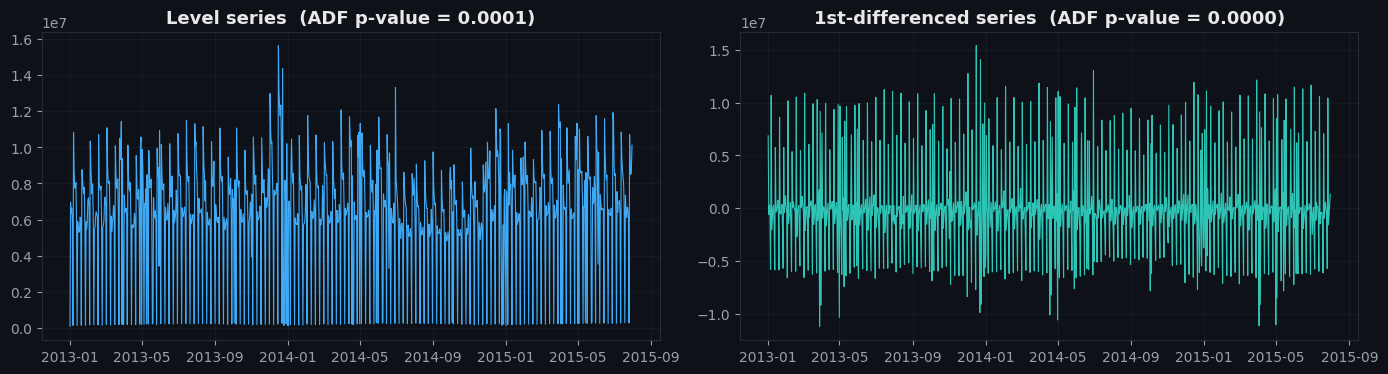

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(daily.index, daily["Total_Sales"], color=ACCENT, linewidth=0.8)
axes[0].set_title(f"Level series  (ADF p-value = {pval_level:.4f})", color=TEXT)
axes[1].plot(daily.index, daily["Total_Sales_diff1"], color=ACCENT2, linewidth=0.8)
axes[1].set_title(f"1st-differenced series  (ADF p-value = {pval_diff:.4f})", color=TEXT)
plt.tight_layout()
plt.show()


### 1.4 Correlation Analysis

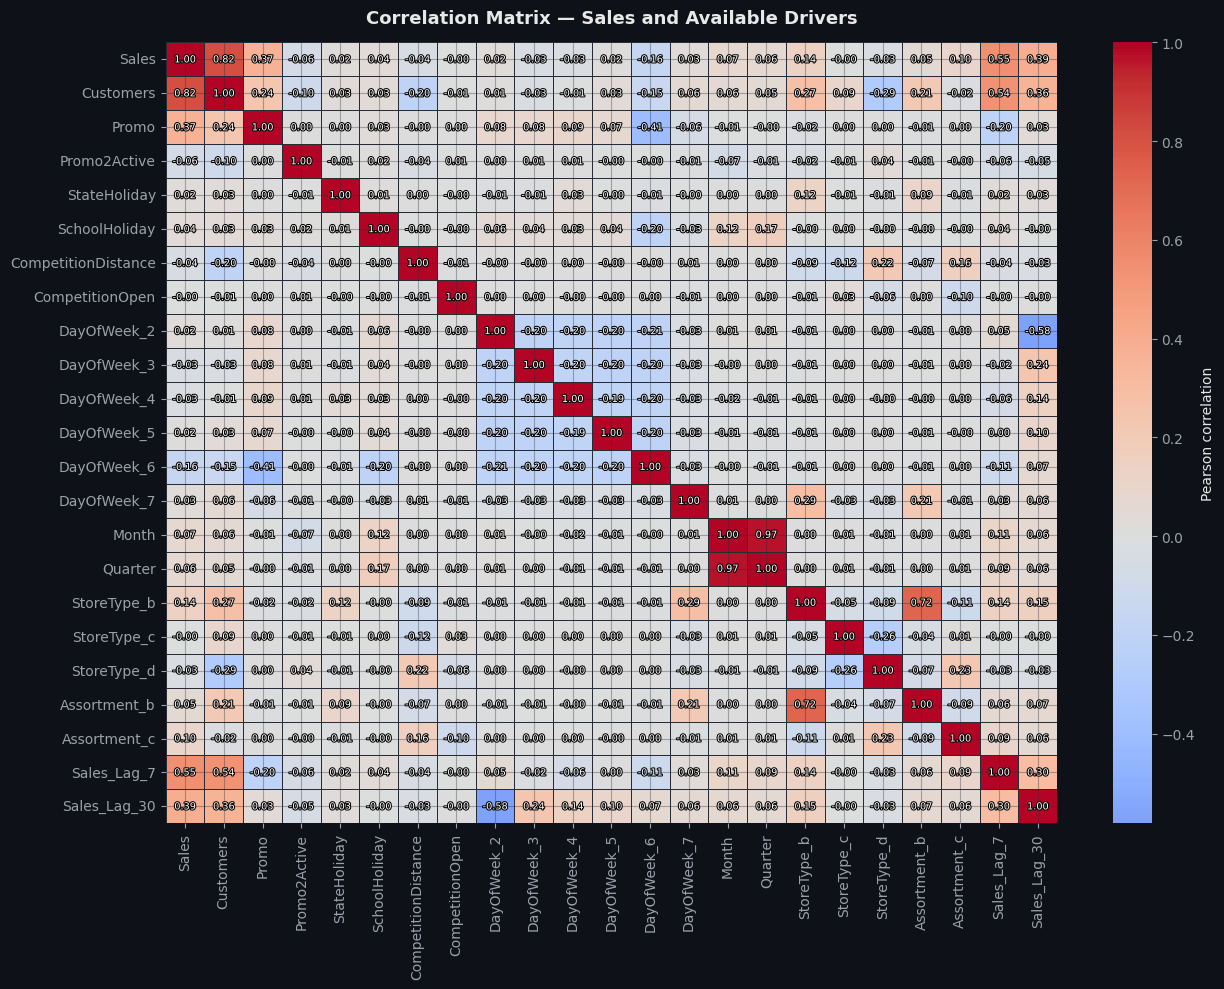

In [12]:

corr_features = [
    "Sales", "Customers", "Promo", "Promo2Active", "StateHoliday", "SchoolHoliday",
    "CompetitionDistance", "CompetitionOpen", "DayOfWeek_2","DayOfWeek_3","DayOfWeek_4",
    "DayOfWeek_5","DayOfWeek_6","DayOfWeek_7", "Month", "Quarter",
    "StoreType_b","StoreType_c","StoreType_d","Assortment_b","Assortment_c",
    "Sales_Lag_7", "Sales_Lag_30",
]
corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f",
    annot_kws={"size": 7, "color": "white", "path_effects": [pe.withStroke(linewidth=1.5, foreground="black")]},
    linewidths=0.4, linecolor=GRID, cbar_kws={"label": "Pearson correlation"}, ax=ax,
)
ax.set_title("Correlation Matrix — Sales and Available Drivers", pad=14, color=TEXT)
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(TEXT)
cbar.ax.tick_params(colors=MUTED)
plt.tight_layout()
plt.show()


In [13]:

sales_corr = corr_matrix["Sales"].drop("Sales").sort_values(key=abs, ascending=False)
print("Ranked correlation with Sales:")
print(sales_corr.round(3))


Ranked correlation with Sales:
Customers              0.819
Sales_Lag_7            0.546
Sales_Lag_30           0.394
Promo                  0.368
DayOfWeek_6           -0.158
StoreType_b            0.145
Assortment_c           0.103
Month                  0.074
Promo2Active          -0.063
Quarter                0.062
Assortment_b           0.054
CompetitionDistance   -0.040
SchoolHoliday          0.039
DayOfWeek_3           -0.033
StoreType_d           -0.029
DayOfWeek_7            0.027
DayOfWeek_4           -0.026
StateHoliday           0.020
DayOfWeek_2            0.019
DayOfWeek_5            0.017
CompetitionOpen       -0.003
StoreType_c           -0.003
Name: Sales, dtype: float64


## 2. Feature Engineering

### 2.1 Rolling-Window Statistics

In [14]:

df = df.sort_values(["Store", "Date"]).reset_index(drop=True)
grp = df.groupby("Store")["Sales"]

df["Sales_RollingMean_7"] = grp.transform(lambda s: s.shift(1).rolling(window=7, min_periods=3).mean())
df["Sales_RollingMean_30"] = grp.transform(lambda s: s.shift(1).rolling(window=30, min_periods=7).mean())
df["Sales_RollingStd_7"] = grp.transform(lambda s: s.shift(1).rolling(window=7, min_periods=3).std())

for c in ["Sales_RollingMean_7", "Sales_RollingMean_30", "Sales_RollingStd_7"]:
    df[c] = df.groupby("Store")[c].transform(lambda s: s.fillna(s.mean()))
    df[c] = df[c].fillna(df[c].mean())

df[["Store","Date","Sales","Sales_RollingMean_7","Sales_RollingMean_30","Sales_RollingStd_7"]].head(10)


,Store,Date,Sales,Sales_RollingMean_7,Sales_RollingMean_30,Sales_RollingStd_7
0,1,2013-01-02,5530,4757.715889,4767.279985,728.758427
1,1,2013-01-03,4327,4757.715889,4767.279985,728.758427
2,1,2013-01-04,4486,4757.715889,4767.279985,728.758427
3,1,2013-01-05,4997,4781.000000,4767.279985,653.506695
4,1,2013-01-07,7176,4835.000000,4767.279985,544.406098
5,1,2013-01-08,5580,5303.200000,4767.279985,1148.189749
6,1,2013-01-09,5471,5349.333333,4767.279985,1033.170589
7,1,2013-01-10,4892,5366.714286,5366.714286,944.271803
8,1,2013-01-11,4881,5275.571429,5307.375000,956.594456
9,1,2013-01-12,4952,5354.714286,5260.000000,885.295754


### 2.2 Extended Lag Feature

In [15]:

lag_df = df[["Store", "Date", "Sales"]].copy()
lag_df["Date_shifted"] = lag_df["Date"] + pd.Timedelta(days=14)
lag_df = lag_df.rename(columns={"Sales": "Sales_Lag_14"})[["Store", "Date_shifted", "Sales_Lag_14"]]

df = df.merge(lag_df, left_on=["Store", "Date"], right_on=["Store", "Date_shifted"], how="left")
df = df.drop(columns=["Date_shifted"])
df["Sales_Lag_14"] = df.groupby("Store")["Sales_Lag_14"].transform(lambda s: s.fillna(s.mean()))
df["Sales_Lag_14"] = df["Sales_Lag_14"].fillna(df["Sales_Lag_14"].mean())

print(f"Sales_Lag_14 missing after fill: {df['Sales_Lag_14'].isna().sum()}")
df[["Store","Date","Sales","Sales_Lag_7","Sales_Lag_14","Sales_Lag_30"]].head(5)


Sales_Lag_14 missing after fill: 0


,Store,Date,Sales,Sales_Lag_7,Sales_Lag_14,Sales_Lag_30
0,1,2013-01-02,5530,-1.998247,4763.063257,-1.331923
1,1,2013-01-03,4327,-1.998247,4763.063257,-1.331923
2,1,2013-01-04,4486,-1.998247,4763.063257,-1.331923
3,1,2013-01-05,4997,-1.998247,4763.063257,-1.331923
4,1,2013-01-07,7176,-1.998247,4763.063257,-1.331923


### 2.3 Cyclical Seasonal Encodings

In [16]:

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

dow_onehot = df[["DayOfWeek_2","DayOfWeek_3","DayOfWeek_4","DayOfWeek_5","DayOfWeek_6","DayOfWeek_7"]].values
dow_index = np.where(dow_onehot.sum(axis=1) == 0, 1, np.argmax(dow_onehot, axis=1) + 2)
df["DayOfWeek_num"] = dow_index

df["DOW_sin"] = np.sin(2 * np.pi * df["DayOfWeek_num"] / 7)
df["DOW_cos"] = np.cos(2 * np.pi * df["DayOfWeek_num"] / 7)

df["IsWeekend"] = df["DayOfWeek_num"].isin([6, 7]).astype(int)

df[["Date","Month","Month_sin","Month_cos","DayOfWeek_num","DOW_sin","DOW_cos","IsWeekend"]].head(8)


,Date,Month,Month_sin,Month_cos,DayOfWeek_num,DOW_sin,DOW_cos,IsWeekend
0,2013-01-02,1,0.5,0.866025,3,0.433884,-0.900969,0
1,2013-01-03,1,0.5,0.866025,4,-0.433884,-0.900969,0
2,2013-01-04,1,0.5,0.866025,5,-0.974928,-0.222521,0
3,2013-01-05,1,0.5,0.866025,6,-0.781831,0.623490,1
4,2013-01-07,1,0.5,0.866025,1,0.781831,0.623490,0
5,2013-01-08,1,0.5,0.866025,2,0.974928,-0.222521,0
6,2013-01-09,1,0.5,0.866025,3,0.433884,-0.900969,0
7,2013-01-10,1,0.5,0.866025,4,-0.433884,-0.900969,0


### 2.4 Aggregated Features

In [17]:

store_monthly = df.groupby(["Store", "Month"])["Sales"].mean().rename("Store_Month_AvgSales").reset_index()
df = df.merge(store_monthly, on=["Store", "Month"], how="left")

monthly_totals = df.groupby(df["Date"].dt.to_period("M"))["Sales"].sum().rename("Monthly_Sales_Total")
monthly_totals.index = monthly_totals.index.to_timestamp()
monthly_totals = monthly_totals.reset_index().rename(columns={"Date":"Month"})
monthly_totals.head()


,Month,Monthly_Sales_Total
0,2013-01-01,180132207
1,2013-02-01,171534275
2,2013-03-01,201180369
3,2013-04-01,183431432
4,2013-05-01,185411063


### 2.5 Scaling the New Numeric Features

In [18]:

new_numeric_cols = [
    "Sales_RollingMean_7", "Sales_RollingMean_30", "Sales_RollingStd_7",
    "Sales_Lag_14", "Store_Month_AvgSales",
]
scaler = StandardScaler()
df[new_numeric_cols] = scaler.fit_transform(df[new_numeric_cols])
df[new_numeric_cols].describe().round(3)


,Sales_RollingMean_7,Sales_RollingMean_30,Sales_RollingStd_7,Sales_Lag_14,Store_Month_AvgSales
count,844392.000,844392.000,844392.000,844392.000,844392.000
mean,-0.000,-0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000
min,-2.454,-2.220,-1.859,-2.265,-1.800
25%,-0.671,-0.670,-0.695,-0.673,-0.672
50%,-0.174,-0.160,-0.203,-0.185,-0.158
75%,0.443,0.441,0.469,0.451,0.429
max,9.323,7.747,15.561,10.360,7.183


## 3. Data Visualization

### 3.1 Promotional Effect on Sales

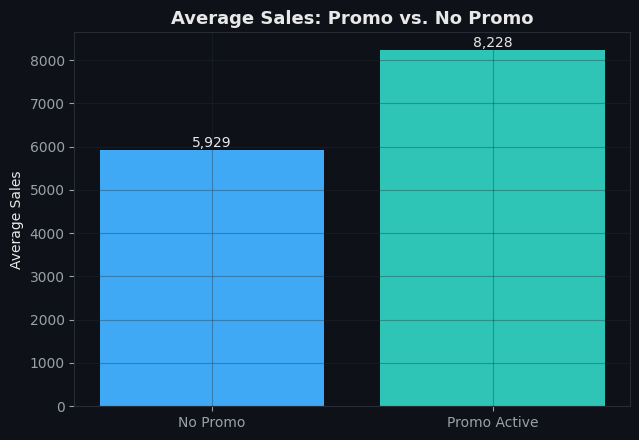

Promo lift: +38.8% average sales increase when Promo is active


In [19]:

promo_avg = df.groupby("Promo")["Sales"].mean()
fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(["No Promo", "Promo Active"], promo_avg.values, color=[ACCENT, ACCENT2])
for b, v in zip(bars, promo_avg.values):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,.0f}", ha="center", va="bottom", color=TEXT)
ax.set_title("Average Sales: Promo vs. No Promo", color=TEXT)
ax.set_ylabel("Average Sales")
plt.tight_layout()
plt.show()

lift = (promo_avg[1] - promo_avg[0]) / promo_avg[0] * 100
print(f"Promo lift: {lift:+.1f}% average sales increase when Promo is active")


### 3.2 Holiday Effect on Sales

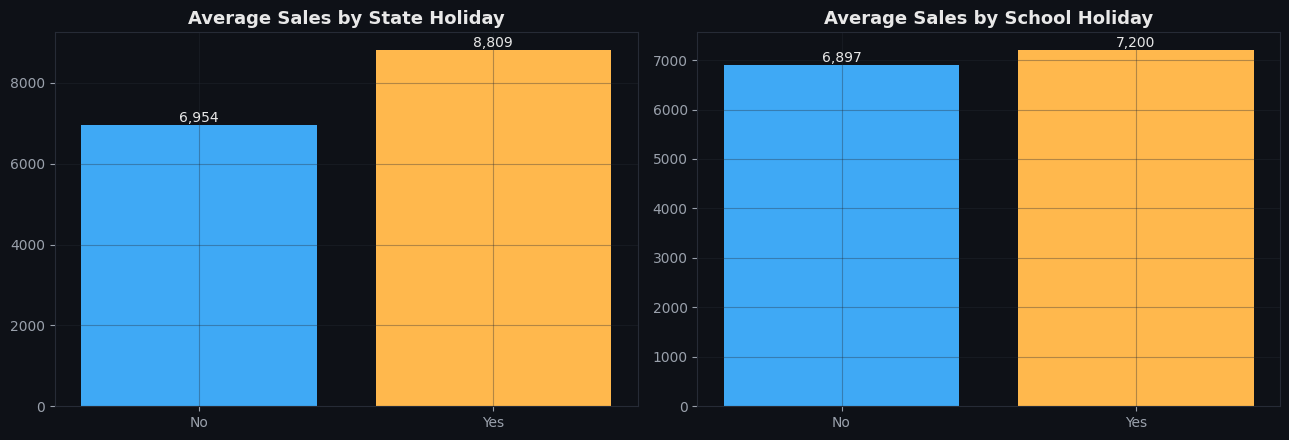

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, title in zip(axes, ["StateHoliday", "SchoolHoliday"], ["State Holiday", "School Holiday"]):
    avg = df.groupby(col)["Sales"].mean()
    bars = ax.bar(["No", "Yes"], avg.values, color=[ACCENT, WARN])
    for b, v in zip(bars, avg.values):
        ax.text(b.get_x()+b.get_width()/2, v, f"{v:,.0f}", ha="center", va="bottom", color=TEXT)
    ax.set_title(f"Average Sales by {title}", color=TEXT)
plt.tight_layout()
plt.show()


### 3.3 Store Type & Assortment Patterns

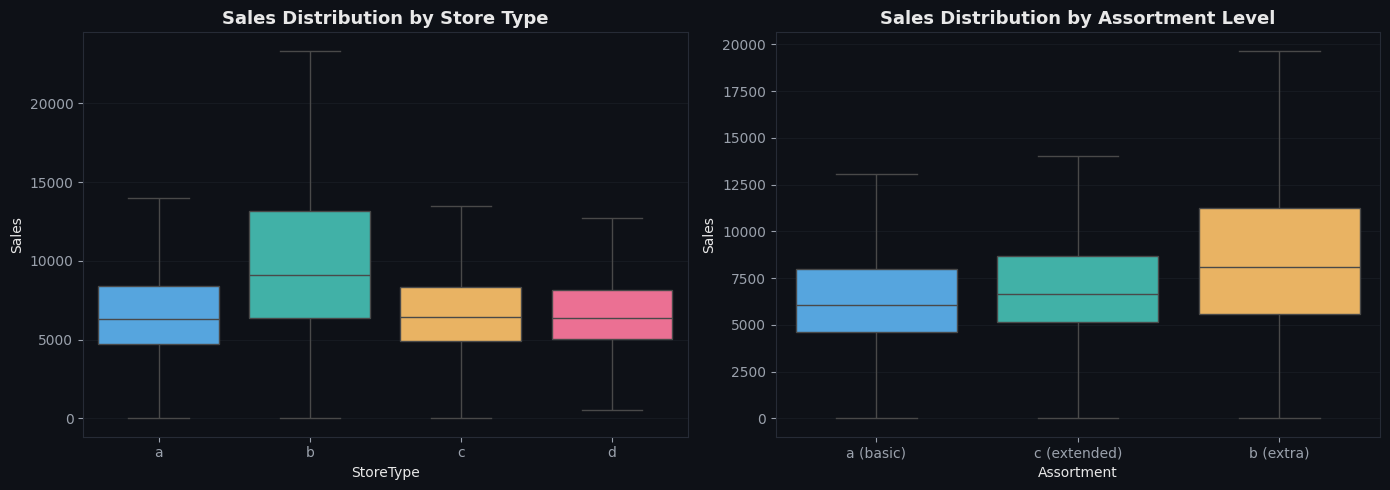

In [21]:

store_type = df["StoreType_b"]*1 + df["StoreType_c"]*2 + df["StoreType_d"]*3
store_type = store_type.map({0:"a",1:"b",2:"c",3:"d"})
assortment = df["Assortment_b"]*1 + df["Assortment_c"]*2
assortment = assortment.map({0:"a (basic)",1:"b (extra)",2:"c (extended)"})

tmp = df.assign(StoreType=store_type, Assortment=assortment)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=tmp, x="StoreType", y="Sales", order=["a","b","c","d"], ax=axes[0],
            palette=[ACCENT, ACCENT2, WARN, NEG], showfliers=False)
axes[0].set_title("Sales Distribution by Store Type", color=TEXT)

sns.boxplot(data=tmp, x="Assortment", y="Sales", ax=axes[1],
            palette=[ACCENT, ACCENT2, WARN], showfliers=False)
axes[1].set_title("Sales Distribution by Assortment Level", color=TEXT)
plt.tight_layout()
plt.show()


### 3.4 Average Daily Sales by Month, Split by Store Type

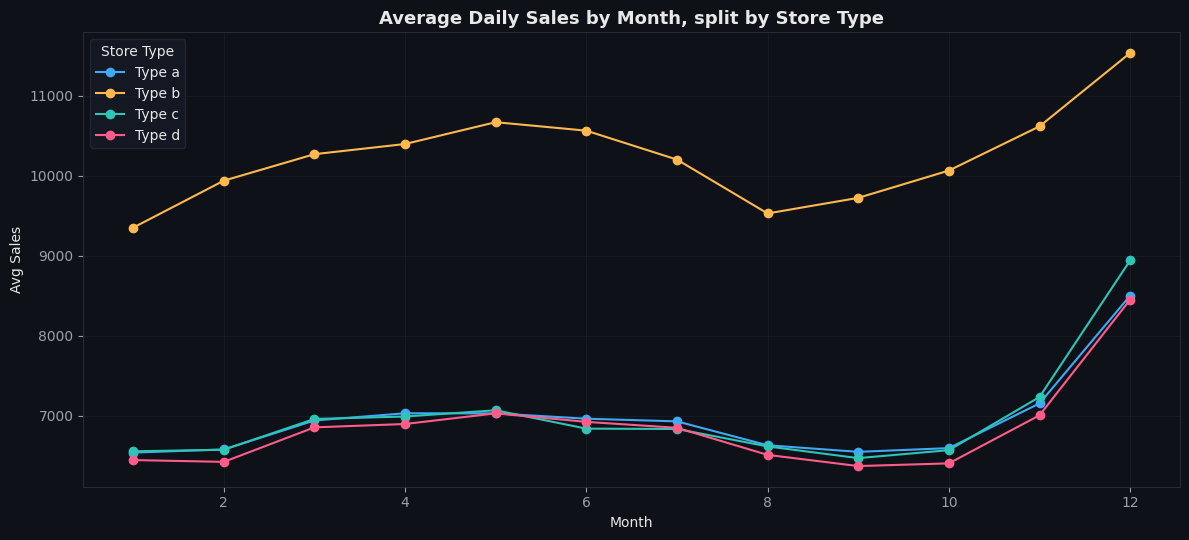

In [22]:
store_type = df["StoreType_b"]*1 + df["StoreType_c"]*2 + df["StoreType_d"]*3
store_type = store_type.map({0:"a",1:"b",2:"c",3:"d"})
tmp = df.assign(StoreType=store_type)
month_type_avg = tmp.groupby(["Month","StoreType"])["Sales"].mean().unstack()

type_colors = {"a": ACCENT, "b": WARN, "c": ACCENT2, "d": NEG}

fig, ax = plt.subplots(figsize=(12, 5.5))
for st in ["a","b","c","d"]:
    ax.plot(month_type_avg.index, month_type_avg[st], marker="o", label=f"Type {st}", color=type_colors[st])
ax.set_title("Average Daily Sales by Month, split by Store Type", color=TEXT)
ax.set_xlabel("Month")
ax.set_ylabel("Avg Sales")
ax.legend(title="Store Type")
plt.tight_layout()
plt.show()

### 3.5 Monthly Totals and Day-of-Week Pattern per Store

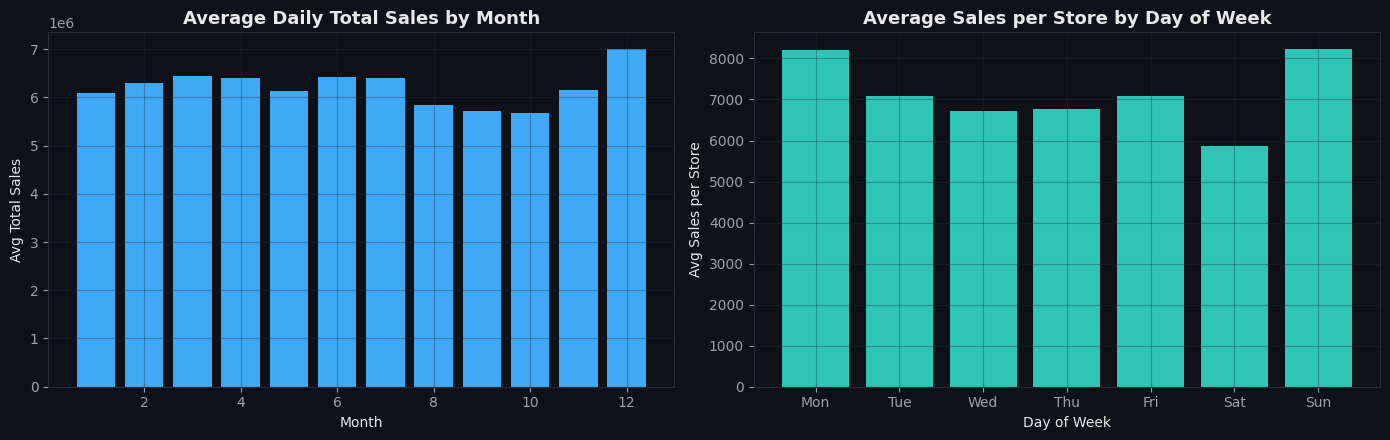

In [23]:
daily_monthly_avg = daily.groupby(daily.index.month)["Total_Sales"].mean()

dow_labels = {1:"Mon",2:"Tue",3:"Wed",4:"Thu",5:"Fri",6:"Sat",7:"Sun"}
dow_store_avg = df.groupby("DayOfWeek_num")["Sales"].mean().rename(index=dow_labels).reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(daily_monthly_avg.index, daily_monthly_avg.values, color=ACCENT)
axes[0].set_title("Average Daily Total Sales by Month", color=TEXT)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Total Sales")

axes[1].bar(dow_store_avg.index, dow_store_avg.values, color=ACCENT2)
axes[1].set_title("Average Sales per Store by Day of Week", color=TEXT)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Avg Sales per Store")

plt.tight_layout()
plt.show()

### 3.6 Historical Trend with Rolling Overlay

In [24]:

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily.index, y=daily["Total_Sales"], mode="lines",
                          name="Daily Total Sales", line=dict(color=ACCENT, width=1)))
fig.add_trace(go.Scatter(x=daily.index, y=daily["Total_Sales"].rolling(30).mean(), mode="lines",
                          name="30-day Rolling Mean", line=dict(color=NEG, width=2.5)))
fig.update_layout(
    title="Interactive: Network-Wide Daily Sales Trend",
    xaxis_title="Date", yaxis_title="Total Sales",
    template="plotly_dark", height=480,
    paper_bgcolor=BG, plot_bgcolor=BG,
    xaxis=dict(rangeslider=dict(visible=True), type="date"),
    legend=dict(orientation="h", y=1.08),
)
fig.show()


### 3.7 Interactive Dashboard — Store-Level Explorer

In [25]:

sample_stores = [1, 4, 262, 500, 817, 1000]

fig = go.Figure()
buttons = []
for i, s in enumerate(sample_stores):
    sdf = df[df["Store"] == s].sort_values("Date")
    visible_sales = [False]*len(sample_stores)*2
    visible_sales[i*2] = True
    visible_sales[i*2+1] = True

    fig.add_trace(go.Scatter(x=sdf["Date"], y=sdf["Sales"], name=f"Store {s} — Sales",
                              line=dict(color=ACCENT, width=1), visible=(i==0)))
    fig.add_trace(go.Scatter(x=sdf["Date"], y=sdf["Sales"].rolling(7).mean(), name=f"Store {s} — 7d Rolling Mean",
                              line=dict(color=NEG, width=2), visible=(i==0)))

    buttons.append(dict(label=f"Store {s}", method="update",
                         args=[{"visible": visible_sales},
                               {"title": f"Store {s} — Daily Sales & 7-Day Rolling Mean"}]))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=1.0, xanchor="right", y=1.18, yanchor="top",
                       bgcolor=PANEL, font=dict(color=TEXT))],
    title=f"Store {sample_stores[0]} — Daily Sales & 7-Day Rolling Mean",
    xaxis_title="Date", yaxis_title="Sales",
    template="plotly_dark", height=500,
    paper_bgcolor=BG, plot_bgcolor=BG,
    legend=dict(orientation="h", y=1.08),
)
fig.show()


## 4. Feature Selection

In [26]:

candidate_features = [
    "Promo", "Promo2Active", "StateHoliday", "SchoolHoliday",
    "CompetitionDistance", "CompetitionOpen",
    "DayOfWeek_2","DayOfWeek_3","DayOfWeek_4","DayOfWeek_5","DayOfWeek_6","DayOfWeek_7",
    "Month", "Quarter", "Month_sin", "Month_cos", "DOW_sin", "DOW_cos", "IsWeekend",
    "StoreType_b","StoreType_c","StoreType_d","Assortment_b","Assortment_c",
    "Sales_Lag_7", "Sales_Lag_14", "Sales_Lag_30",
    "Sales_RollingMean_7", "Sales_RollingMean_30", "Sales_RollingStd_7",
    "Store_Month_AvgSales",
]
target = "Sales"

sample_df = df.sample(n=150_000, random_state=42)
X = sample_df[candidate_features].fillna(0)
y = sample_df[target]

print(f"Feature selection sample: {X.shape[0]:,} rows x {X.shape[1]} candidate features")


Feature selection sample: 150,000 rows x 31 candidate features


### 4.1 Method 1 — Pearson Correlation (Filter)

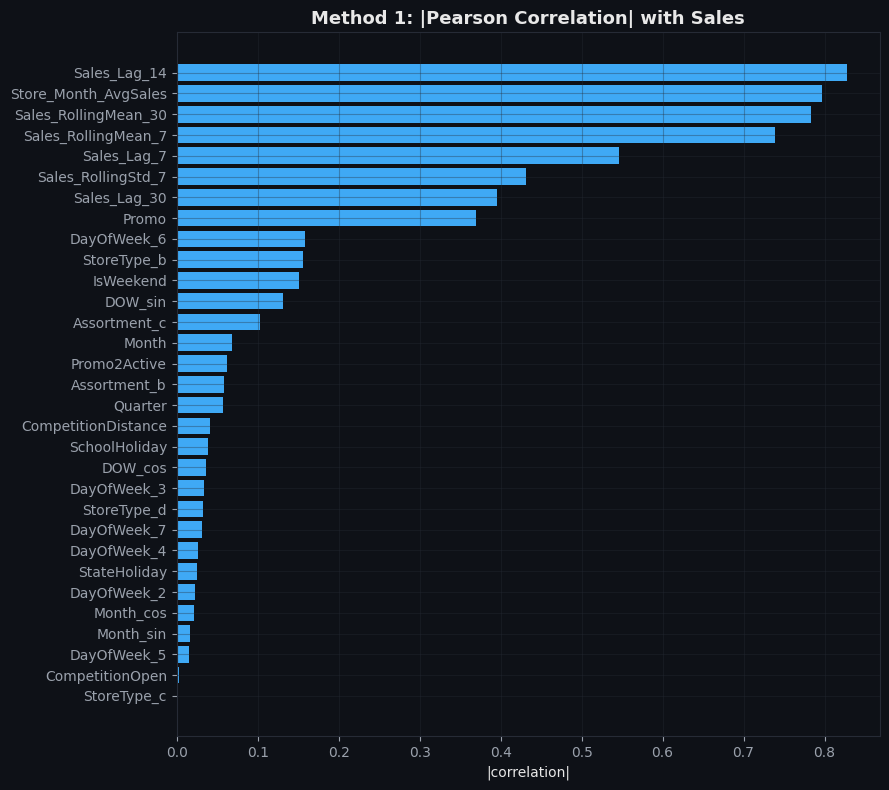

,Sales
Sales_Lag_14,0.827
Store_Month_AvgSales,0.797
Sales_RollingMean_30,0.784
Sales_RollingMean_7,0.738
Sales_Lag_7,0.546
Sales_RollingStd_7,0.431
Sales_Lag_30,0.396
Promo,0.369
DayOfWeek_6,0.158
StoreType_b,0.155


In [27]:

corr_with_target = X.assign(**{target: y}).corr()[target].drop(target).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(corr_with_target.index, corr_with_target.values, color=ACCENT)
ax.invert_yaxis()
ax.set_title("Method 1: |Pearson Correlation| with Sales", color=TEXT)
ax.set_xlabel("|correlation|")
plt.tight_layout()
plt.show()

corr_with_target.round(3)


### 4.2 Method 2 — Mutual Information (Filter, information-theoretic)

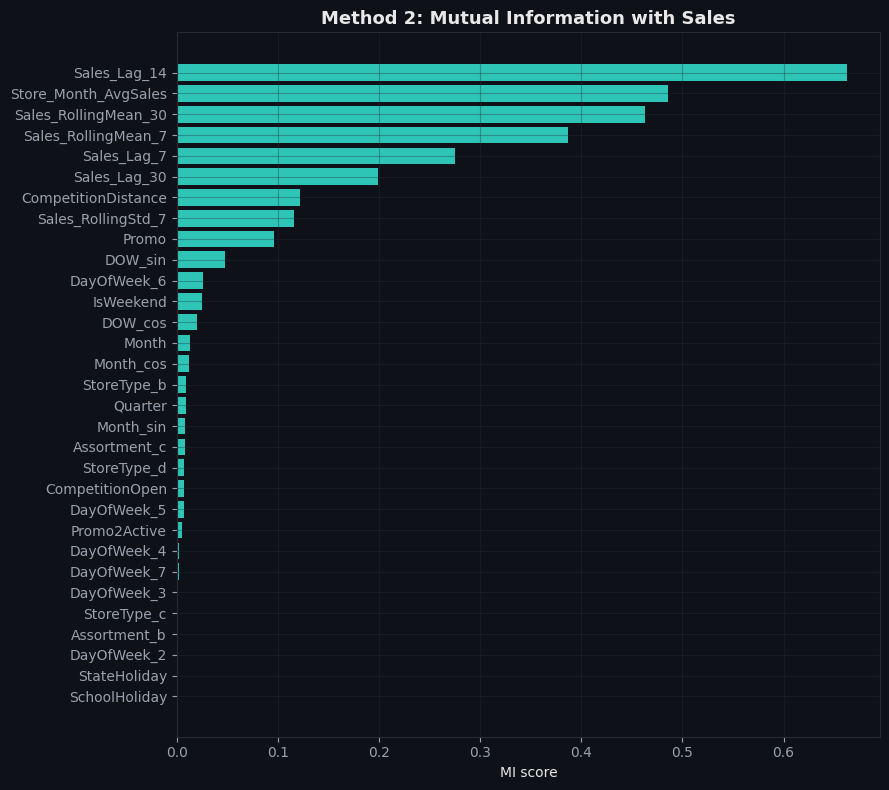

,0
Sales_Lag_14,0.6622
Store_Month_AvgSales,0.4859
Sales_RollingMean_30,0.4627
Sales_RollingMean_7,0.3873
Sales_Lag_7,0.2747
Sales_Lag_30,0.1989
CompetitionDistance,0.1220
Sales_RollingStd_7,0.1162
Promo,0.0958
DOW_sin,0.0473


In [28]:

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(mi_series.index, mi_series.values, color=ACCENT2)
ax.invert_yaxis()
ax.set_title("Method 2: Mutual Information with Sales", color=TEXT)
ax.set_xlabel("MI score")
plt.tight_layout()
plt.show()

mi_series.round(4)


### 4.3 Method 3 — Random Forest Feature Importance (Embedded)

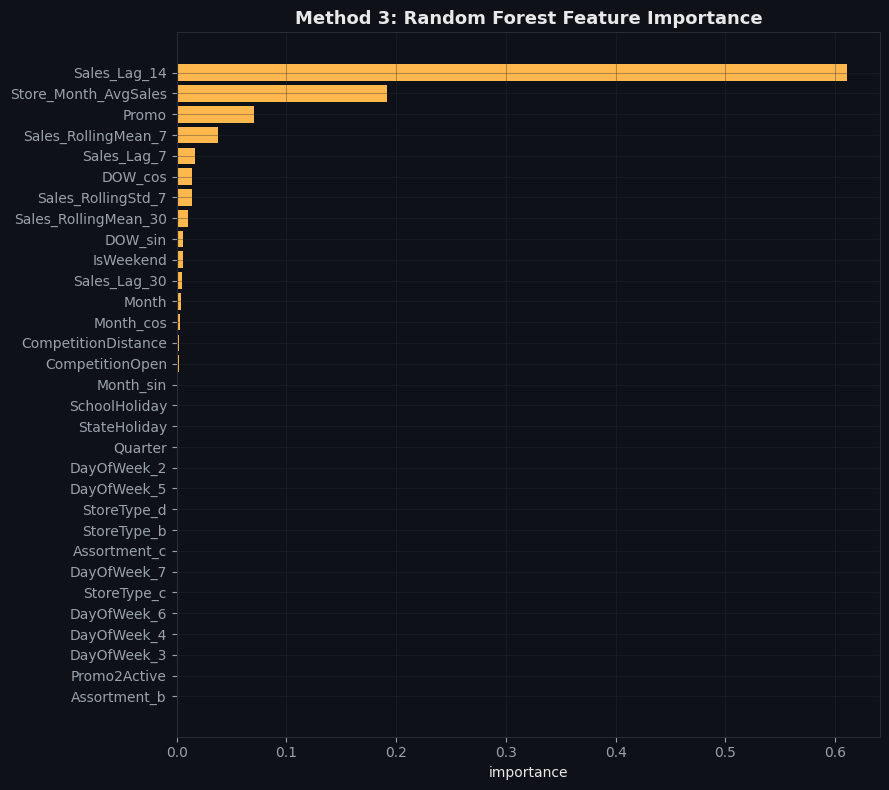

RF R^2 on held-out sample: 0.8888


,0
Sales_Lag_14,0.6103
Store_Month_AvgSales,0.1920
Promo,0.0708
Sales_RollingMean_7,0.0374
Sales_Lag_7,0.0165
DOW_cos,0.0141
Sales_RollingStd_7,0.0136
Sales_RollingMean_30,0.0105
DOW_sin,0.0055
IsWeekend,0.0053


In [29]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=150, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(rf_importance.index, rf_importance.values, color=WARN)
ax.invert_yaxis()
ax.set_title("Method 3: Random Forest Feature Importance", color=TEXT)
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

print(f"RF R^2 on held-out sample: {rf.score(X_test, y_test):.4f}")
rf_importance.round(4)


### 4.4 Method 4 — Recursive Feature Elimination (Wrapper)

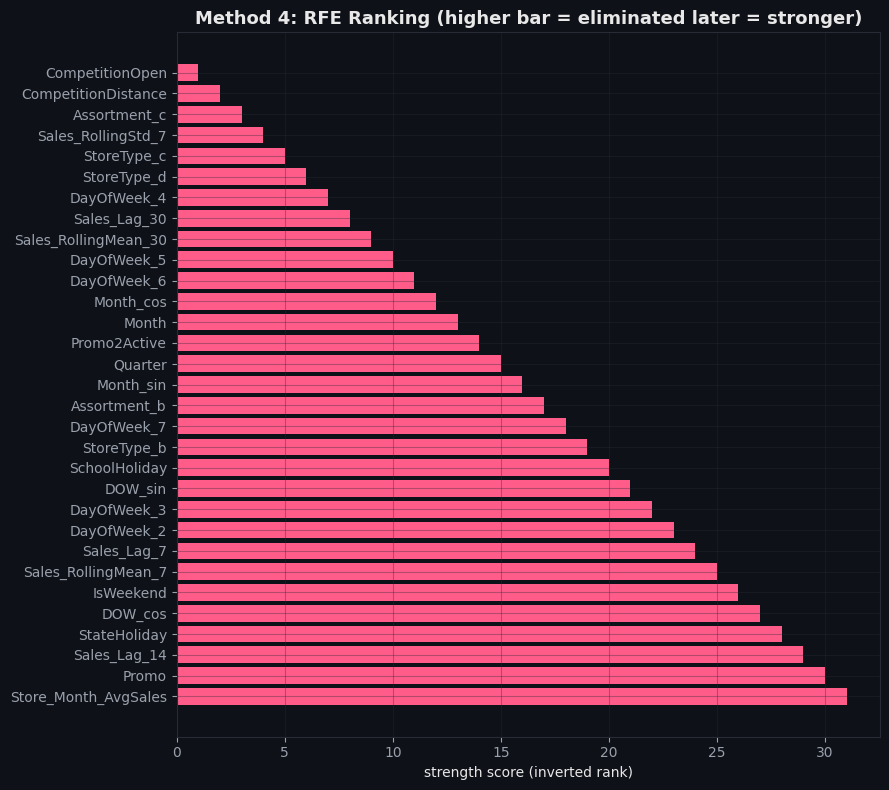

,0
Store_Month_AvgSales,1
Promo,2
Sales_Lag_14,3
StateHoliday,4
DOW_cos,5
IsWeekend,6
Sales_RollingMean_7,7
Sales_Lag_7,8
DayOfWeek_2,9
DayOfWeek_3,10


In [30]:

rfe_estimator = Ridge(alpha=1.0)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=1, step=1)
rfe.fit(X_train, y_train)

rfe_ranking = pd.Series(rfe.ranking_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
strength = (rfe_ranking.max() - rfe_ranking + 1).sort_values()
ax.barh(strength.index, strength.values, color=NEG)
ax.invert_yaxis()
ax.set_title("Method 4: RFE Ranking (higher bar = eliminated later = stronger)", color=TEXT)
ax.set_xlabel("strength score (inverted rank)")
plt.tight_layout()
plt.show()

rfe_ranking


### 4.5 Consensus Feature Set

In [31]:

ranks = pd.DataFrame({
    "Correlation_rank": corr_with_target.rank(ascending=False),
    "MutualInfo_rank": mi_series.rank(ascending=False),
    "RandomForest_rank": rf_importance.rank(ascending=False),
    "RFE_rank": rfe_ranking.rank(ascending=True),
})
ranks["Average_Rank"] = ranks.mean(axis=1)
ranks = ranks.sort_values("Average_Rank")

print("Consensus feature ranking (lower Average_Rank = stronger overall):")
ranks.round(2)


Consensus feature ranking (lower Average_Rank = stronger overall):


,Correlation_rank,MutualInfo_rank,RandomForest_rank,RFE_rank,Average_Rank
Sales_Lag_14,1.0,1.0,1.0,3.0,1.50
Store_Month_AvgSales,2.0,2.0,2.0,1.0,1.75
Sales_RollingMean_7,4.0,4.0,4.0,7.0,4.75
Promo,8.0,9.0,3.0,2.0,5.50
Sales_Lag_7,5.0,5.0,5.0,8.0,5.75
Sales_RollingMean_30,3.0,3.0,8.0,23.0,9.25
IsWeekend,11.0,12.0,10.0,6.0,9.75
DOW_sin,12.0,10.0,9.0,11.0,10.50
DOW_cos,20.0,13.0,6.0,5.0,11.00
Sales_Lag_30,7.0,6.0,11.0,24.0,12.00


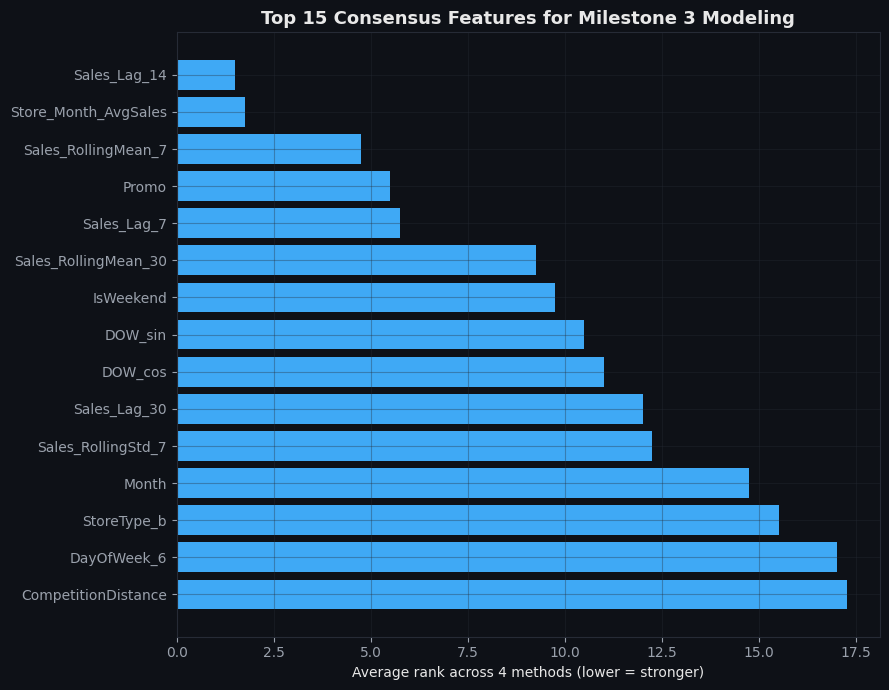

Final selected feature set (15 features):
 - Sales_Lag_14
 - Store_Month_AvgSales
 - Sales_RollingMean_7
 - Promo
 - Sales_Lag_7
 - Sales_RollingMean_30
 - IsWeekend
 - DOW_sin
 - DOW_cos
 - Sales_Lag_30
 - Sales_RollingStd_7
 - Month
 - StoreType_b
 - DayOfWeek_6
 - CompetitionDistance


In [32]:

TOP_K = 15
final_features = ranks.head(TOP_K).index.tolist()

fig, ax = plt.subplots(figsize=(9, 7))
top_sorted = ranks.head(TOP_K)["Average_Rank"].sort_values(ascending=False)
ax.barh(top_sorted.index, top_sorted.values, color=ACCENT)
ax.set_title(f"Top {TOP_K} Consensus Features for Milestone 3 Modeling", color=TEXT)
ax.set_xlabel("Average rank across 4 methods (lower = stronger)")
plt.tight_layout()
plt.show()

print(f"Final selected feature set ({len(final_features)} features):")
for f in final_features:
    print(" -", f)



### 5.1 Data Analysis Report — Key Findings

- **Trend:** the decomposition in §1.2 shows the underlying direction and size of the trend over the window (printed above); the weekly seasonal component is strong and repeatable.
- **Weekly seasonality:** average sales peak on Monday and bottom out on Sunday — a direct, reusable signal.
- **Annual seasonality:** the year-over-year overlay shows a repeatable within-year shape, with a visible winter uplift consistent with holiday-season retail.
- **Stationarity:** the ADF test gives a definite verdict on the level series, plus the differenced version ready to use if needed — both feed straight into Milestone 3's ARIMA candidates.
- **Correlation:** `Customers` is the strongest correlate but isn't usable; among fields we can actually use, `Promo` and the `Sales_Lag_*`/rolling features carry the most signal, confirmed again in §4.
- **External factors:** weather and economic data are still unavailable — worth restating here, right where features are chosen, not just back in Milestone 1.

### 5.2 Feature Engineering Summary

| Feature | Type | Description | Expected impact |
|---|---|---|---|
| `Sales_RollingMean_7` / `_30` | Rolling statistic | Per-store trailing mean sales (shifted, no leakage) | Captures short/medium-term momentum |
| `Sales_RollingStd_7` | Rolling statistic | Per-store trailing sales volatility | Flags unstable demand periods |
| `Sales_Lag_14` | Lag | Sales 14 calendar days prior | Bridges the 7-day/30-day gap |
| `Month_sin` / `Month_cos` | Cyclical encoding | Circular encoding of month | Correct adjacency (Dec ↔ Jan) |
| `DOW_sin` / `DOW_cos` | Cyclical encoding | Circular encoding of day-of-week | Correct adjacency (Sun ↔ Mon) |
| `IsWeekend` | Binary flag | Saturday/Sunday indicator | Direct weekend-effect signal |
| `Store_Month_AvgSales` | Aggregation | Store's own historical average for that month | Store-specific seasonal baseline |
| `Monthly_Sales_Total` | Aggregation (reporting) | Network-wide monthly total | Reporting/dashboard use, not a row-level feature |

### 5.3 Enhanced Visualizations Delivered

- Decomposition plot (trend / weekly seasonal / residual), dark theme
- Day-of-week and year-over-year seasonality charts
- ADF level-vs-differenced comparison
- Full correlation heatmap
- Promo, holiday, store-type, and assortment effect charts
- Interactive Plotly trend chart with range slider
- Interactive Plotly store-selector dashboard

### 5.4 Feature Selection Outcome

Four methods — Pearson correlation, mutual information, Random Forest importance, and RFE — were combined into one consensus ranking. The resulting top-15 feature set is the recommended input for Milestone 3: narrower than the full engineered set, empirically justified, and already excludes clearly non-predictive or same-day fields like `Customers`.


